#### ตัวอย่างการเขียนโปรแกรมและใช้งาน การถดถอยเชิงเส้น (Linear Regression) ในการสร้างโมเดลเพื่อทำนายและวิเคราะห์ข้อมูล 

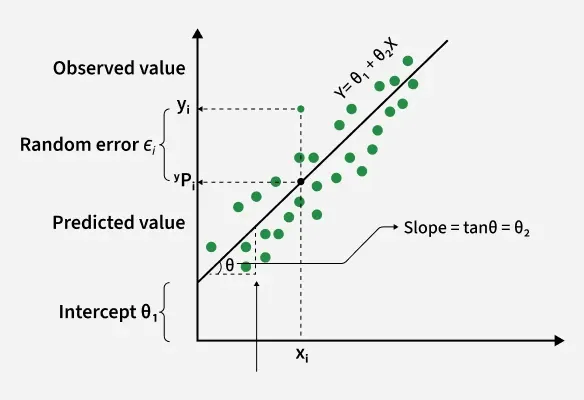

Linear Regression 

การถดถอยเชิงเส้น (Linear Regression) คือ โมเดลพื้นฐานของ Machine Learning หรือ Statistics Learing สำหรับการสร้างโมเดลเพื่อวิเคราะห์หาแนวโน้ม หรือทำนายจากข้อมูลที่มีอยู่

มีสมการสำคัญคือ $\hat{y_i}=\theta_0+\theta_1x \\$
$\hat{y_i}$ คือ output, target 
$\\ x$ คือ input, features 
$\\ \theta_0$ คือ จุดตัดแกน Y ของโมเดล  
$\\ \theta_1$ คือ ความชันของโมเดล 

และสามารถวัดประสิทธิภาพของโมเดลด้วยเครื่องมือต่าง ๆ แต่ในไฟล์นี้จะมีการใช้งาน MSE (Mean Squared Error) เป็นการวัดว่าโมเดลของเรามีความผิดพลาดจากค่าจริงมากน้อยเท่าไหร่

สมการสำหรับการหา MSE (Mean Squared Error) คือ $\frac{1}{n}\sum{^i_n}{(y_i-\hat{y_i})^2}\\$
$n$ คือ จำนวนของข้อมูล 
$\\ y_i$ คือ ข้อมูลจริง ๆ 
$\\ \hat{y_i}$ คือ ข้อมูลที่ได้มีการทำนายจากโมเดล


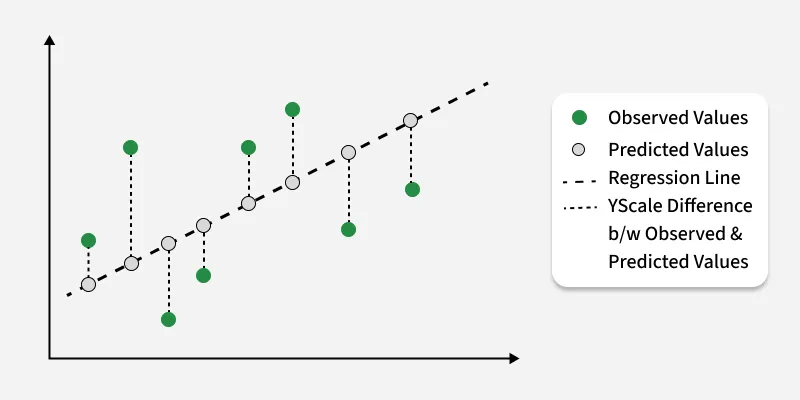

Mean Squared Error : MSE

โดย Dataset ที่เราได้มีการเอามาใช้งาน แหล่งอ้างอิง https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/

เป็นข้อมูลที่เกี่ยวข้องกับการใช้เชื้อเพลิงน้ำมันของรถยนต์ โดย Goals ของการสร้าง model นี้คือ เราต้องการจะทำนายว่าแรงม้าของรถยนต์ส่งผลต่อการกินพลังงานน้ำมันในหน่วย ไมล์ต่อแกลลอนไหม ด้วยการใช้งาน Linear Regression

In [ ]:
"""
    เริ่มต้นจากการ Download เครื่องมือสำคัญที่จำเป็น ได้แก่
    1. numpy สำหรับการคำนวณสำคัญ
    2. matplotlib สำหรับการพล็อตกราฟ
    3. pandas สำหรับการจัดการไฟล์
    4. scikit-learn สำหรับการสร้างโมเดล machine learning
"""
%pip install numpy matplotlib pandas
%pip install --upgrade scikit-learn 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

#1. ทำการตรวจสอบ Dataset ของเราก่อนว่าข้อมูลที่เราสนใจมีข้อผิดพลาดหรือไม่ ?
nameData = "dataset_linear_regression.csv"
dataset = pd.read_csv(nameData)
print("แสดงผลข้อมูลใน 5 บรรทัดแรก")
print(dataset.head())

#ตรวจสอบประเภทของข้อมูลที่สนใจว่าเป็นข้อมูลประเภทเดียวกันไหม ?
print("ตรวจสอบประเภทของข้อมูล")
print(dataset.info())


พบว่าที่ horsepower ของเราเป็นประเภทข้อมูลแบบ object หมายความว่า ข้อมูลของเราอาจจะมีได้หลายประเภท ดังนั้น สิ่งที่เราจะต้องทำคือ เปลี่ยนข้อมูลของเราที่ไม่ใช่ตัวเลขเป็น NaN จากนั้นทำการคัดออก

In [ ]:
#ขั้นตอน 2 การเตรียมข้อมูล จัดการประเภทของข้อมูลให้ตรงกัน !
df = pd.read_csv(nameData)

#ทำการเลือก Column "horsepower" จากนั้นทำการเปลี่ยนประเภทของข้อมูลนี้เป็นตัวเลข 
#หากไม่สามารถเปลี่ยนได้จะทำการ Return ออกมาเป็น NaN แทน
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print(df.info())

df = df.dropna(subset=['horsepower'])

In [ ]:
from sklearn.model_selection import train_test_split
X = df[['horsepower']]    #สร้างตัวแปรสำหรับการเก็บ Features ตัวแปรไม่อิสระ
Y = df['mpg']           #สร้างตัวแปรสำหรับการเก็บ Features ตัวแปรอิสระ

#ทำการแบ่งข้อมูลของเราออกเป็น 2 กลุ่ม คือ Train_set และ Test_set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score 

#แสดงผลความชันและจุดตัดแกน y เพื่อสร้างเป็นสมการสำหรับการใส่ใน Linear Equation
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope of Linear equation : {slope}")
print(f"Intercept of Linear equation : {intercept}")

#สร้างคำสั่งสำหรับการทำนายโมเดลจากข้อมูลทดสอบ
y_pred = model.predict(X_test)

#คำนวณความแม่นยำด้วย MSE, R^2 Errors
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f"Mean Squared Error : {mse}")
print(f"R-squared Error : {r2}")

Slope of Linear equation : -0.16259724322918453
Intercept of Linear equation : 40.606097600118346
Mean Squared Error : 22.153237123863413
R-squared Error : 0.5659681822256185


In [ ]:
plt.scatter(X_train, Y_train, color='blue',label='Actual Data')
plt.plot(X_test, y_pred, color='red', label="Regression Line")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Simple Linear Regression : horsepower vs mpg')
plt.legend()
plt.savefig('results.png')

สามารถสรุปผลได้ว่า "ยิ่งกำลังแรงม้าของเครื่องยนต์มีค่ามากขึ้น (horsepower) อัตราการประหยัดพลังงานจะลดลง (mpg)" 

$R^2 \approx 0.56$ มีความหมายว่า กำลังแรงม้าส่งผลต่อการเปลี่ยนแปลงของอัตราการประพยัดพลังงานประมาณ 56% และมีข้อมูลอื่น ๆ ที่มีส่วนเกี่ยวข้องอีก 44%

$MSE \approx 22.15$ มีความหมายว่า ค่าความผิดพลาดกำลังสองของโมเดลได้มีการทำนายผิดพลาดไปอยู่ที่ประมาณ 22.15 mpg หรือเมื่อถอดรากที่สองออกจะมีค่าอยู่ที่ประมาณ $4.71$ ซึ่งหมายความว่า โมเดลของเราสามารถทำนายได้ผิดพลาดไป $ \pm 4.71$ mpg